# MNIST Digit Classification: from Fully Connected to CNN

In this lab we build and train two classifiers for handwritten digits from the famous [MNIST](http://yann.lecun.com/exdb/mnist/) dataset: 60,000 training images and 10,000 test images, with the digits 0-9 as classes.

We start with a simple **fully connected network**, measure its accuracy, then rebuild the classifier as a **convolutional neural network (CNN)** and see how much the ability to exploit the spatial structure of images pays off. At the end we visualize the predictions, including the confidence the model assigns to each digit.

## Running this notebook on Kaggle

This notebook is designed to run on **Kaggle**, which gives us a free GPU and a clean way to store API keys. To set it up:

1. Create a new Notebook on [Kaggle](https://www.kaggle.com/code) and import this file (File > Import Notebook);
2. In the notebook settings, set **Accelerator** to a GPU (for example a T4 or P100) and make sure **Internet** is enabled;
3. Create a free account on [Comet](https://www.comet.com), which we will use to track our experiments, and copy your **API key** from your account settings;
4. Back on Kaggle, open **Add-ons > Secrets**, create a secret with label `COMET_API_KEY`, paste your key as the value, and attach it to this notebook.

The key is read through `kaggle_secrets`, so it never appears in the code. If you run this elsewhere (Colab, local machine), just replace that block with your own way of loading the key.

One note on dependencies: the `mitdeeplearning` package is a small utility library from the open MIT deep learning course. We only use it here for a couple of plotting helpers.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

# utility library, used here for the plotting helpers
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

# other packages
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 26.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 86.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.2 MB/

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
!pip install comet_ml > /dev/null 2>&1
from kaggle_secrets import UserSecretsClient

import comet_ml
user_secrets = UserSecretsClient()
COMET_API_KEY = user_secrets.get_secret("COMET_API_KEY")

assert torch.cuda.is_available(), "Please enable the GPU accelerator in the Kaggle notebook settings"
assert COMET_API_KEY != "", "Please insert your Comet API Key"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
comet_ml.login(api_key=COMET_API_KEY)
comet_model_1 = comet_ml.start(project_name="mnist-digit-classification-fc")

COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorflow, sklearn, keras, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/salvatore-borda/6s191-lab2-part1-nn/3e606093ff334e4aa76293572e680bdc



In [7]:
transform = transforms.Compose([
    # a func to convert images to PyTorch tensors which also scales data from [0,255] to [0,1]
    transforms.ToTensor()
])
# Download training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
100%|██████████| 9.91M/9.91M [00:00<00:00, 53.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


The MNIST dataset object in PyTorch is not a simple tensor or array. It is an **iterable dataset** that returns one (image, label) pair at a time. Later we will wrap it in a `DataLoader` to read it in batches.

In [8]:
image, label = train_dataset[0]
print(image.size())
print(label)
# 1 color channel, 28 height, 28 width

torch.Size([1, 28, 28])
5


Our training set is made up of 28x28 grayscale images of handwritten digits. Let's visualize some of them together with their labels, to get a feel for what the model will actually see.

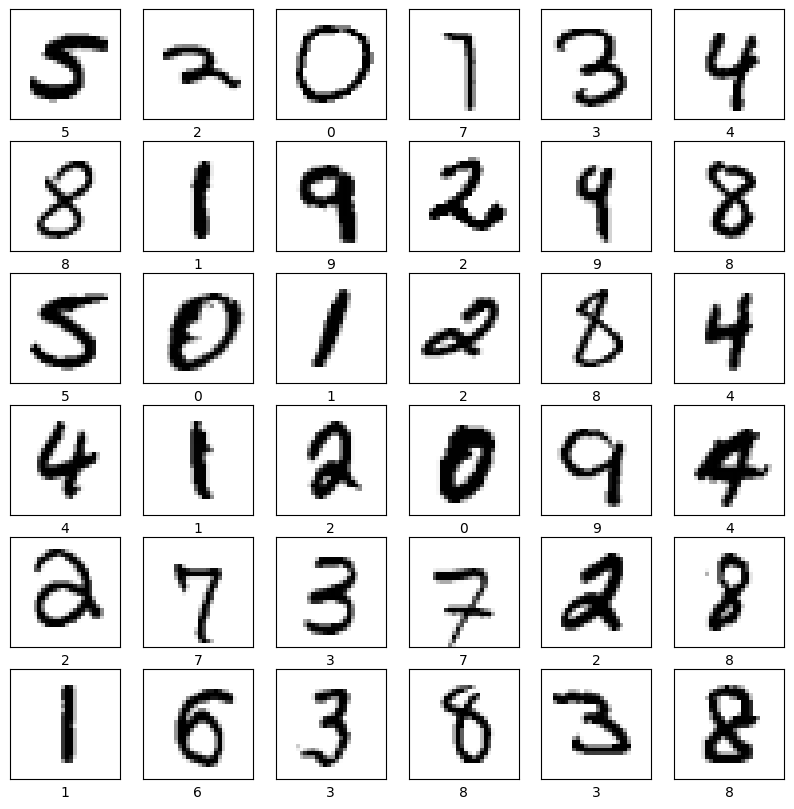

In [9]:
plt.figure(figsize=(10,10))
random_inds = np.random.choice(60000,36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    image, label = train_dataset[image_ind]
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(label)
comet_model_1.log_figure(figure=plt)
plt.show()

## A first model: fully connected network

We start with the simplest reasonable architecture: two fully connected layers. The network takes an image as input and outputs 10 scores, one for each digit class (0-9). The class with the highest score is the model's guess.

To define this first network we use the `torch.nn` modules, building the model with `nn.Sequential`. Note the `nn.Flatten` layer at the beginning: it flattens the 2D image into a 1D vector, so it can be fed to the linear layers.

In [10]:
def build_fc_model():
    fc_model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )
    return fc_model
fc_model_sequential = build_fc_model()

As we move forward you may want to tweak this architecture. Keep in mind that to update the model you need to re-run the cell above, so that it gets re-initialized.

Let's take a step back and look at what we just built. The first layer, `nn.Flatten`, transforms each image from a 2D array of 28x28 pixels into a 1D array of 784 pixels. You can picture it as taking the rows of pixels and lining them up one after the other. There is nothing to learn in this layer: it only reformats the data.

After flattening, the network is a sequence of two `nn.Linear` (fully connected) layers. The first has 128 neurons with a ReLU activation. The second outputs 10 numbers, one per digit class. Careful with one detail: these outputs are **logits**, raw scores, not probabilities. It will be the loss function (cross entropy) that applies the softmax internally to turn them into a probability distribution.

That defines our fully connected model!

### The same model, subclassing nn.Module

`nn.Sequential` is fine for simple stacks, but the standard PyTorch way is to **subclass `nn.Module`**: we declare the layers in `__init__` and describe how data flows through them in `forward`. It is more verbose, but it gives us total control, and it is the pattern we will use for every model from now on.

In [11]:
class FullyConnectedModel(nn.Module):
    def __init__(self):
        super(FullyConnectedModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
fc_model = FullyConnectedModel().to(device)

### Loss, optimizer and metrics

Before training we need to define the components that guide the learning process:

- **Loss function**: measures how wrong the model is during training. Training means minimizing this function, which "steers" the model in the right direction;
- **Optimizer**: defines how the weights get updated based on the data and the loss;
- **Metrics**: what we monitor along the way. Here we will track the **accuracy**, the fraction of images classified correctly.

We start with **stochastic gradient descent (SGD)** and a learning rate of 0.1. Since this is a multi-class classification task, the natural choice for the loss is **cross entropy**.

Try experimenting with both the optimizer and the learning rate, and observe how they affect the accuracy of the trained model.

In [12]:
# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(fc_model.parameters(), lr=0.1)

### Training

Time to train: we feed the training data to the model and ask it to learn the association between images and labels. Two more ingredients are needed:

- the **batch size**: how many images we process at each step;
- the number of **epochs**: how many complete passes over the dataset we make.

We define a PyTorch `DataLoader` to iterate over the dataset in batches, and a `train` function built on the classic loop: forward pass, loss, `loss.backward()` for the gradients, `optimizer.step()` to update weights and biases.

In [13]:
BATCH_SIZE = 64
trainset_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
def train(model, dataloader, criterion, optimizer, epochs):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        total_loss = 0
        correct_pred = 0
        total_pred = 0
        
        for images, labels in trainset_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = fc_model(images)
            
            optimizer.zero_grad()
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # loss.item() is the average loss over the batch, so we multiply it by
            # the batch size (images.size(0)) to get the total (summed) loss for this batch.
            # This lets us correctly average over all samples later, even if the last
            # batch has a different size than the others.
            total_loss += loss.item()*images.size(0)
            
            # Calculate accuracy
            predicted = torch.argmax(outputs, dim=1)  # Get predicted class
            correct_pred += (predicted == labels).sum().item()  # Count correct predictions
            total_pred += labels.size(0) # Count total predictions
            
        # Compute metrics
        total_epoch_loss = total_loss / total_pred
        epoch_accuracy = correct_pred / total_pred
        print(f"Epoch {epoch + 1}, Loss: {total_epoch_loss}, Accuracy: {epoch_accuracy:.4f}")

In [15]:
EPOCHS = 5
train(fc_model, trainset_loader, loss_function, optimizer, EPOCHS)

comet_model_1.end()

Epoch 1, Loss: 0.44274485772450767, Accuracy: 0.8818
Epoch 2, Loss: 0.22789811817804972, Accuracy: 0.9347
Epoch 3, Loss: 0.17125808884898822, Accuracy: 0.9506
Epoch 4, Loss: 0.13740510878761608, Accuracy: 0.9609


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : static_detail_2602
COMET INFO:     url                   : https://www.comet.com/salvatore-borda/6s191-lab2-part1-nn/3e606093ff334e4aa76293572e680bdc
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     figures             : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 1
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorflow, sklearn, keras, torch.


Epoch 5, Loss: 0.11479977328677972, Accuracy: 0.9670


COMET INFO: Please wait for metadata to finish uploading (timeout is 3600 seconds)
COMET INFO: Uploading 24 metrics, params and output messages


### Evaluation on the test set

Now that the model is trained, let's ask it to predict on a test set it has never seen. Iterating over `testset_loader` gives us test images and labels, and to measure accuracy we simply check whether the predictions match the labels.

Since we are only measuring, we switch the model to **eval mode** and disable gradient tracking.

You will probably notice that the test accuracy is a bit lower than the training accuracy: that gap is a small example of **overfitting**, the model performing worse on new data than on the data it trained on.

In [16]:
def evaluate(model, dataloader, loss_function):
    # Evaluate model performance on the test dataset
    model.eval()
    test_loss = 0
    correct_pred = 0
    total_pred = 0
    # Disable gradient calculations when in inference mode
    with torch.no_grad():
        for images, labels in testset_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = loss_function(outputs, labels)

            test_loss += loss.item()*images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct_pred += (predicted == labels).sum().item()
            total_pred += labels.size(0)

    # Compute average loss and accuracy
    test_loss /= total_pred
    test_acc = correct_pred / total_pred
    return test_loss, test_acc
    
test_loss, test_acc = evaluate(fc_model, testset_loader, loss_function)

print('Test accuracy:', test_acc)

Test accuracy: 0.9672


## Switching to a Convolutional Neural Network (CNN)

The fully connected network works, but it throws away the spatial structure of the image: after the flatten, two neighboring pixels are just two unrelated numbers. Convolutional networks are built exactly to exploit that structure. Let's see how much we gain.

CNNs are particularly well suited for computer vision tasks, and have reached near-perfect accuracy on MNIST. We will build a CNN made of two convolutional layers, each followed by a pooling layer, then two fully connected layers, ending with the usual 10 scores for the digit classes (0-9). This is the architecture:

![CNN](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab2/img/convnet_fig.png)

We use the same training and test datasets as before, and proceed just like with the fully connected network. Two new layers come into play: `nn.Conv2d` for the convolutional layers and `nn.MaxPool2d` for the pooling layers. We define them with the parameters shown in the architecture above. You can choose `nn.Sequential` or subclassing `nn.Module`, based on your preference: here we go with subclassing.

In [20]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 24, 3)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(24, 36, 3)
        self.pool2 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(36 * 5 * 5, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        # First convolutional and pooling layers
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

# Instantiate the model
cnn_model = CNN().to(device)
# Initialize the model by passing some data through
image, label = train_dataset[0]
image = image.to(device).unsqueeze(0)  # Add batch dimension → Shape: (1, 1, 28, 28)
output = cnn_model(image)
# Print the model summary
print(cnn_model)

CNN(
  (conv1): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(24, 36, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=900, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Train and test the CNN

Same recipe as before: loss, optimizer, DataLoader, training loop. This time we also log the loss to Comet at every step and plot it live, so we can watch the training in real time. At the end, we evaluate on the test set and compare the accuracy with the fully connected model.

In [24]:
cnn_model = CNN().to(device)
batch_size = 64
epochs = 7
optimizer = optim.SGD(cnn_model.parameters(), lr=1e-2)
loss_function = nn.CrossEntropyLoss()
trainset_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

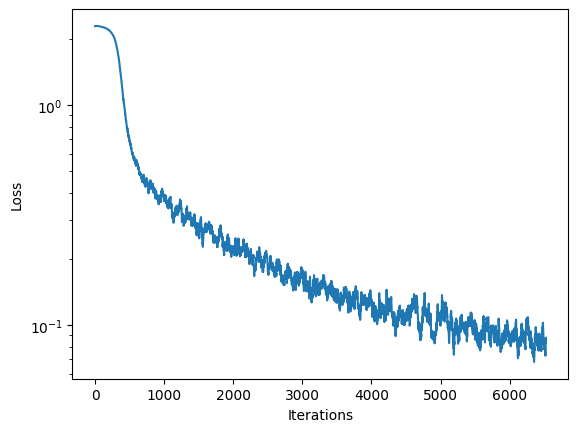

100%|██████████| 938/938 [00:09<00:00, 94.44it/s] 


Epoch 7, Loss: 0.08870935936172804, Accuracy: 0.9730


{'web': 'https://www.comet.com/api/image/download?imageId=2c634ed692e14d68a96e551b760f323d&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=2c634ed692e14d68a96e551b760f323d&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'imageId': '2c634ed692e14d68a96e551b760f323d'}

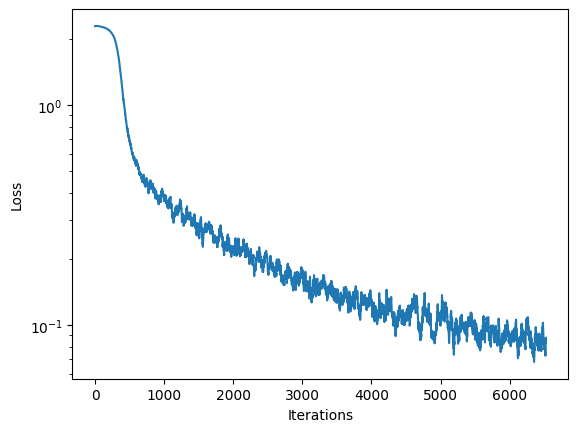

In [25]:
loss_history = mdl.util.LossHistory(smoothing_factor=0.95) # to record the evolution of the loss
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss', scale='semilogy')

# Initialize a new comet experiment
comet_model_2 = comet_ml.start(project_name="mnist-digit-classification-cnn")

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

# Training loop!
cnn_model.train()

for epoch in range(epochs):
    total_loss = 0
    correct_pred = 0
    total_pred = 0
    
    for idx, (images, labels) in enumerate(tqdm(trainset_loader)):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        logits = cnn_model(images)
        loss = loss_function(logits, labels)

        # Get the loss and log it to comet and the loss_history record
        loss_value = loss.item()
        comet_model_2.log_metric("loss", loss_value, step=idx)
        loss_history.append(loss_value) # append the loss to the loss_history record
        plotter.plot(loss_history.get())

        # Backpropagation/backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Get the prediction and tally metrics
        predicted = torch.argmax(logits, dim=1)
        correct_pred += (predicted == labels).sum().item()
        total_pred += labels.size(0)
        total_loss += loss.item() * images.size(0)

    # Compute metrics
    total_epoch_loss = total_loss / total_pred
    epoch_accuracy = correct_pred / total_pred
    print(f"Epoch {epoch + 1}, Loss: {total_epoch_loss}, Accuracy: {epoch_accuracy:.4f}")

comet_model_2.log_figure(figure=plt)

In [27]:
test_loss, test_acc = evaluate(cnn_model, testset_loader, loss_function)

print('Test accuracy:', test_acc)

Test accuracy: 0.9771


### Making predictions

With the model trained, let's use it on a single image. We put it in **eval mode** and run a forward pass on the first image of the test set: the output is a vector of 10 logits, one per digit. The highest one is the model's prediction, and we can verify it against the true label.

In [29]:
test_image, test_label = test_dataset[0]
test_image = test_image.to(device).unsqueeze(0)

# put the model in evaluation (inference) mode
cnn_model.eval()
predictions_test_image = cnn_model(test_image)
print(predictions_test_image)

tensor([[  0.4062,  -3.3757,   3.4130,   3.3087,  -4.4326,  -2.1084, -13.6154,
          12.9930,  -1.7461,   2.0135]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [33]:
predictions_value = predictions_test_image.cpu().detach().numpy()
prediction = np.argmax(predictions_value, axis=1)
print(prediction)

[7]


Label of this digit is: 7


{'web': 'https://www.comet.com/api/image/download?imageId=291e5757a8dd4c589bd7f1eed3425e65&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=291e5757a8dd4c589bd7f1eed3425e65&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'imageId': '291e5757a8dd4c589bd7f1eed3425e65'}

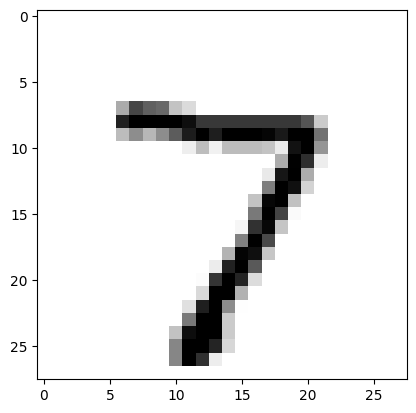

In [34]:

print("Label of this digit is:", test_label)
plt.imshow(test_image[0,0,:,:].cpu(), cmap=plt.cm.binary)
comet_model_2.log_figure(figure=plt)

### Visualizing the predictions

Let's collect predictions, labels and images for the whole test set. We apply the softmax to the logits to obtain real probabilities, then plot images along with the probability the model assigned to each digit. Watch out for one thing: the model can be very confident even when it is wrong!

In [36]:
# Initialize variables to store all data
all_predictions = []
all_labels = []
all_images = []

# Process test set in batches
with torch.no_grad():
    for images, labels in testset_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)

        # Apply softmax to get probabilities from the predicted logits
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        # Get predicted classes
        predicted = torch.argmax(probabilities, dim=1)

        all_predictions.append(probabilities)
        all_labels.append(labels)
        all_images.append(images)

all_predictions = torch.cat(all_predictions)  # Shape: (total_samples, num_classes)
all_labels = torch.cat(all_labels)            # Shape: (total_samples,)
all_images = torch.cat(all_images)            # Shape: (total_samples, 1, 28, 28)

# Convert tensors to NumPy for compatibility with plotting functions
predictions = all_predictions.cpu().numpy()  # Shape: (total_samples, num_classes)
test_labels = all_labels.cpu().numpy()       # Shape: (total_samples,)
test_images = all_images.cpu().numpy()       # Shape: (total_samples, 1, 28, 28)

{'web': 'https://www.comet.com/api/image/download?imageId=f5dcc53715f7427393051de5491900c6&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=f5dcc53715f7427393051de5491900c6&experimentKey=458ee21507b2452f90aeb05d82a07341',
 'imageId': 'f5dcc53715f7427393051de5491900c6'}

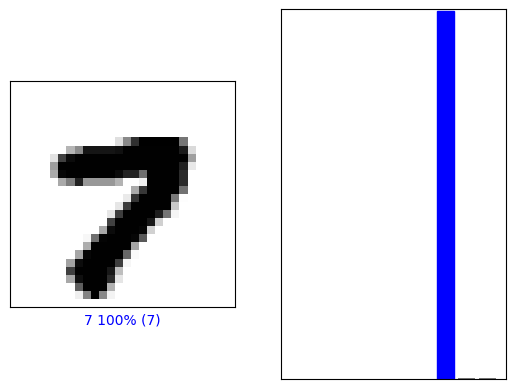

In [37]:
#@title Change the slider to look at the model's predictions! { run: "auto" }

image_index = 79 #@param {type:"slider", min:0, max:100, step:1}
plt.subplot(1,2,1)
mdl.lab2.plot_image_prediction(image_index, predictions, test_labels, test_images)
plt.subplot(1,2,2)
mdl.lab2.plot_value_prediction(image_index, predictions, test_labels)
comet_model_2.log_figure(figure=plt)

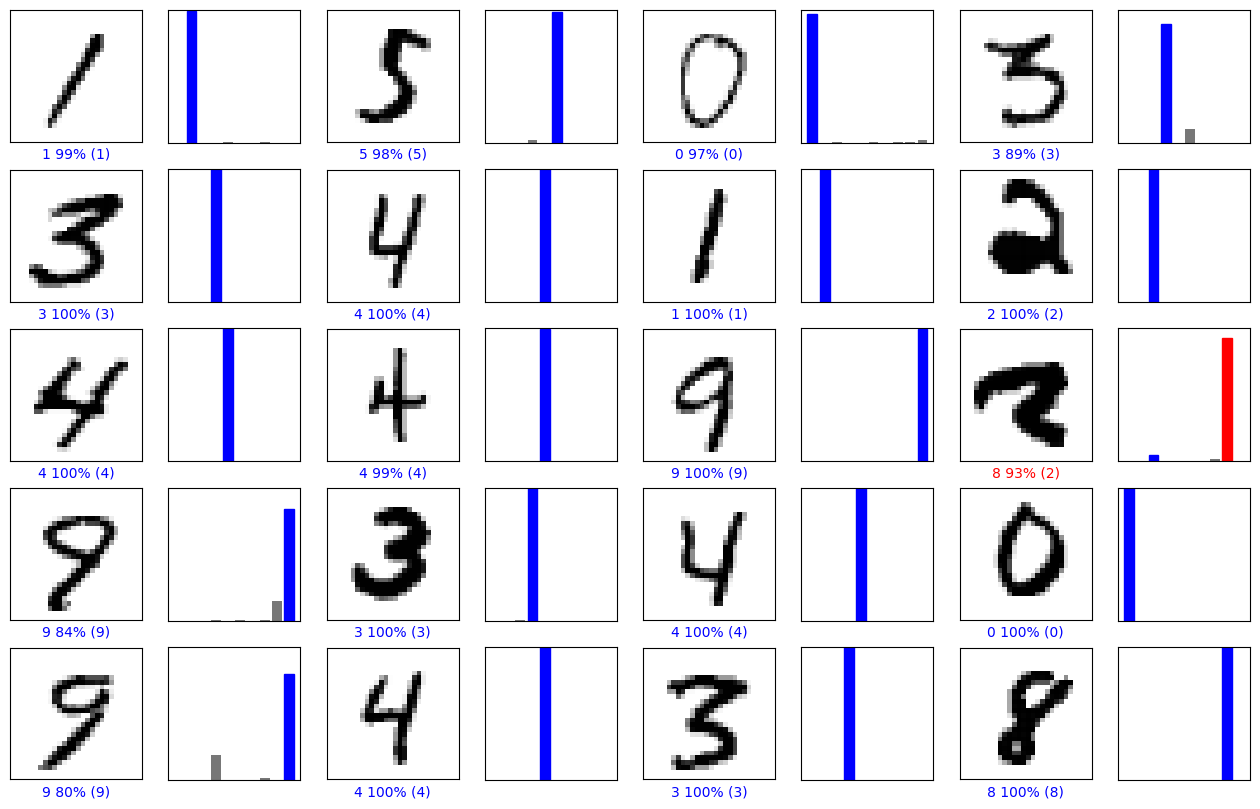

In [46]:
num_rows = 5
num_cols = 4
num_images = num_rows*num_cols

# pick random indices (without repetition) among all the test set images
random_indices = np.random.choice(len(test_labels), num_images, replace=False)

plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for plot_idx, i in enumerate(random_indices):
  plt.subplot(num_rows, 2*num_cols, 2*plot_idx+1)
  mdl.lab2.plot_image_prediction(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*plot_idx+2)
  mdl.lab2.plot_value_prediction(i, predictions, test_labels)
comet_model_2.log_figure(figure=plt)